# Proyecto 1 — ML (CS3061): Clasificación de *Churn* en Telco

**Curso:** Machine Learning · UTEC  
**Dataset:** Telco Customer Churn, usando los archivos oficiales `train.csv` y `test.csv`.  
**Seed:** 42 (replicabilidad garantizada).

Este notebook contiene el pipeline completo:
1. Preprocesamiento + Feature Engineering
2. EDA
3. Modelos: Regresión Logística + Random Forest con CV estratificada y GridSearch
4. Matriz de costos + threshold óptimo para análisis costo-beneficio
5. Submission con threshold optimizado por F1-score para Kaggle/Cadem
6. Generación de predicciones finales sobre `test.csv`

## 0. Setup

In [111]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn imbalanced-learn

    pytz>=2011n
        ~~~~~~^


In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, confusion_matrix, classification_report)

SEED = 42
np.random.seed(SEED)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

In [113]:
train_raw = pd.read_csv("../train.csv")
test_raw = pd.read_csv("../test.csv")

# Por ahora trabajaremos solo con train_raw, porque tiene la variable objetivo Churn.
# test_raw se usará al final solo para predicciones finales.
df_raw = train_raw.copy()

print("Train shape:", train_raw.shape)
print("Test shape:", test_raw.shape)

print("\n¿Train tiene Churn?", "Churn" in train_raw.columns)
print("¿Test tiene Churn?", "Churn" in test_raw.columns)

display(train_raw.head())
display(test_raw.head())

Train shape: (5634, 21)
Test shape: (1409, 20)

¿Train tiene Churn? True
¿Test tiene Churn? False


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,4223-BKEOR,Female,0,No,Yes,21,Yes,No,DSL,Yes,...,Yes,No,No,Yes,One year,No,Mailed check,64.85,1336.8,No
1,6035-RIIOM,Female,0,No,No,54,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Two year,Yes,Bank transfer (automatic),97.20,5129.45,No
2,3797-VTIDR,Male,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,23.45,23.45,Yes
3,2568-BRGYX,Male,0,No,No,4,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.20,237.95,Yes
4,2775-SEFEE,Male,0,No,Yes,0,Yes,Yes,DSL,Yes,...,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,,No


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,1024-GUALD,Female,0,Yes,No,1,No,No phone service,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,24.80,24.8
1,0484-JPBRU,Male,0,No,No,41,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),25.25,996.45
2,3620-EHIMZ,Female,0,Yes,Yes,52,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.35,1031.7
3,6910-HADCM,Female,0,No,No,1,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Electronic check,76.35,76.35
4,8587-XYZSF,Male,0,No,No,67,Yes,No,DSL,No,No,No,Yes,No,No,Two year,No,Bank transfer (automatic),50.55,3260.1


## 1. Preprocesamiento

Pasos:
- Se cargaron los archivos oficiales `train.csv` y `test.csv`.
- El archivo `train.csv` se utilizó para entrenamiento, validación y evaluación interna, ya que contiene la variable objetivo `Churn`.
- El archivo `test.csv` no contiene `Churn`, por lo que se reservó únicamente para generar predicciones finales.
- Se eliminó `customerID` como variable predictora, conservándolo solo para identificar las predicciones finales del test oficial.
- `TotalCharges`: conversión de string a float e imputación de valores faltantes usando la mediana calculada solo con el conjunto de entrenamiento.
- Se colapsó `No internet service` → `No` en las 6 columnas de servicios de internet y `No phone service` → `No` en `MultipleLines`.
- **Feature engineering**: se crearon 4 variables nuevas: `tenure_bucket`, `avg_charges_per_month`, `num_services` e `is_new_customer`.
- Encoding: variables binarias transformadas a 0/1 y variables multiclase codificadas con One-Hot Encoding usando `drop_first=True`.
- Se alinearon las columnas del train y del test oficial para asegurar que ambos tengan las mismas variables después del encoding.
- Se realizó una división estratificada 80/20 del `train.csv`: 80% para train interno y 20% para validación.
- `StandardScaler` fue ajustado solo con el train interno y luego aplicado a validación y test oficial para evitar data leakage.

In [114]:
SERVICE_COLS = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

SCALED_NUMERIC = ['tenure', 'MonthlyCharges', 'TotalCharges',
                  'avg_charges_per_month', 'num_services']


def clean(df, total_charges_median=None):
    df = df.copy()
    # Guardamos customerID si existe, pero no lo usamos como feature
    if 'customerID' in df.columns:
        df = df.drop(columns=['customerID'])
    # Convertir TotalCharges a numérico
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    # La mediana debe salir del train, no del test
    if total_charges_median is None:
        total_charges_median = df['TotalCharges'].median()
    df['TotalCharges'] = df['TotalCharges'].fillna(total_charges_median)
    # Unificar categorías equivalentes
    for c in SERVICE_COLS:
        df[c] = df[c].replace({'No internet service': 'No'})
    df['MultipleLines'] = df['MultipleLines'].replace({'No phone service': 'No'})
    return df, total_charges_median


def feature_engineer(df):
    df = df.copy()
    df['tenure_bucket'] = pd.cut(
        df['tenure'],
        bins=[-0.1, 12, 24, 48, 100],
        labels=['0-12m', '12-24m', '24-48m', '48m+']
    ).astype(str)
    df['avg_charges_per_month'] = df['TotalCharges'] / df['tenure'].replace(0, 1)
    services = SERVICE_COLS + ['PhoneService', 'MultipleLines']
    df['num_services'] = sum((df[c] == 'Yes').astype(int) for c in services)
    df['is_new_customer'] = (df['tenure'] <= 6).astype(int)
    return df


def encode_features(df):
    df = df.copy()
    # Variables binarias
    df['gender'] = (df['gender'] == 'Male').astype(int)
    for c in ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']:
        df[c] = (df[c] == 'Yes').astype(int)
    for c in SERVICE_COLS + ['MultipleLines']:
        df[c] = (df[c] == 'Yes').astype(int)
    # One-hot encoding
    cat = ['InternetService', 'Contract', 'PaymentMethod', 'tenure_bucket']
    df = pd.get_dummies(df, columns=cat, drop_first=True, dtype=int)

    return df

In [115]:
# =========================
# Preprocesamiento train/test
# =========================

# Guardar IDs del test oficial para el archivo final de predicciones
test_customer_ids = test_raw['customerID'].copy()

# Separar variable objetivo del train
y = (train_raw['Churn'] == 'Yes').astype(int)
X_raw = train_raw.drop(columns=['Churn'])

# Limpiar train y obtener mediana del train
X_clean, total_charges_median = clean(X_raw)

# Limpiar test usando la mediana del train
X_test_oficial_clean, _ = clean(test_raw, total_charges_median=total_charges_median)

# Feature engineering
X_fe = feature_engineer(X_clean)
X_test_oficial_fe = feature_engineer(X_test_oficial_clean)

# Encoding
X_enc = encode_features(X_fe)
X_test_oficial_enc = encode_features(X_test_oficial_fe)

# Alinear columnas para que train y test oficial tengan exactamente las mismas features
X_enc, X_test_oficial_enc = X_enc.align(
    X_test_oficial_enc,
    join='left',
    axis=1,
    fill_value=0
)

print("Shape X train completo:", X_enc.shape)
print("Shape test oficial:", X_test_oficial_enc.shape)
print("Churn rate train completo:", y.mean().round(3))

Shape X train completo: (5634, 29)
Shape test oficial: (1409, 29)
Churn rate train completo: 0.266


In [116]:
# =========================
# División interna del train.csv
# =========================

X_train, X_val, y_train, y_val = train_test_split(
    X_enc,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print(f"Train interno: {X_train.shape}")
print(f"Validation: {X_val.shape}")

print(f"Churn rate train={y_train.mean():.3f}")
print(f"Churn rate val={y_val.mean():.3f}")

Train interno: (4507, 29)
Validation: (1127, 29)
Churn rate train=0.266
Churn rate val=0.265


In [117]:
# =========================
# Escalado numérico
# =========================

scaler = StandardScaler()

X_train[SCALED_NUMERIC] = scaler.fit_transform(X_train[SCALED_NUMERIC])
X_val[SCALED_NUMERIC] = scaler.transform(X_val[SCALED_NUMERIC])
X_test_oficial_enc[SCALED_NUMERIC] = scaler.transform(X_test_oficial_enc[SCALED_NUMERIC])

print("Escalado aplicado correctamente.")

Escalado aplicado correctamente.


## 2. EDA

In [118]:
# =========================
# EDA - Exploratory Data Analysis
# =========================

# Usamos solo train_raw porque es el único archivo que contiene la variable objetivo Churn
df_eda = train_raw.copy()

# Convertir TotalCharges a numérico para análisis
df_eda['TotalCharges'] = pd.to_numeric(df_eda['TotalCharges'], errors='coerce')
df_eda['TotalCharges'] = df_eda['TotalCharges'].fillna(df_eda['TotalCharges'].median())

print("Shape train:", df_eda.shape)
print("Churn rate:", (df_eda['Churn'] == 'Yes').mean().round(3))
df_eda.head()

Shape train: (5634, 21)
Churn rate: 0.266


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,4223-BKEOR,Female,0,No,Yes,21,Yes,No,DSL,Yes,...,Yes,No,No,Yes,One year,No,Mailed check,64.85,1336.80,No
1,6035-RIIOM,Female,0,No,No,54,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Two year,Yes,Bank transfer (automatic),97.20,5129.45,No
2,3797-VTIDR,Male,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,23.45,23.45,Yes
3,2568-BRGYX,Male,0,No,No,4,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.20,237.95,Yes
4,2775-SEFEE,Male,0,No,Yes,0,Yes,Yes,DSL,Yes,...,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,1410.80,No


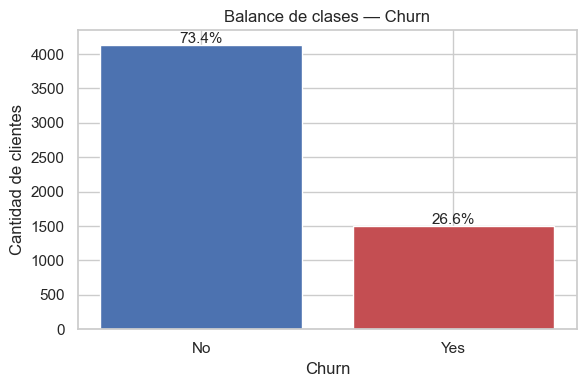

In [119]:
# Figura 1: Balance de clases
counts = df_eda['Churn'].value_counts()
pct = counts / counts.sum() * 100
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(counts.index, counts.values, color=['#4C72B0', '#C44E52'])
for b, p in zip(bars, pct.values):
    ax.text(
        b.get_x() + b.get_width()/2,
        b.get_height() + 30,
        f'{p:.1f}%',
        ha='center'
    )
ax.set_title('Balance de clases — Churn')
ax.set_xlabel('Churn')
ax.set_ylabel('Cantidad de clientes')
plt.tight_layout()
plt.show()

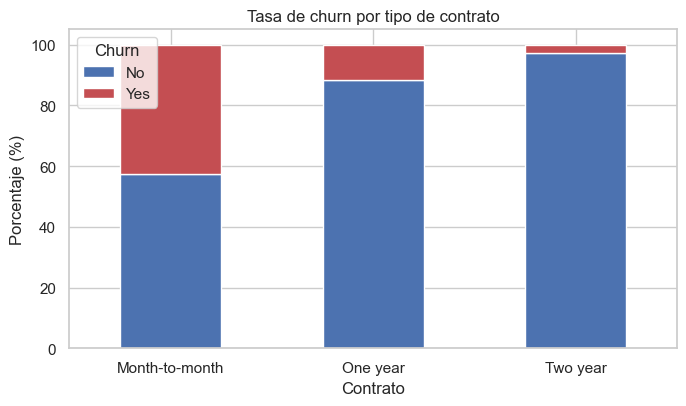

Churn             No   Yes
Contract                  
Month-to-month  57.3  42.7
One year        88.2  11.8
Two year        97.2   2.8


In [120]:
# Figura 2: Churn por contrato
ct = pd.crosstab(
    df_eda['Contract'],
    df_eda['Churn'],
    normalize='index'
) * 100

ct = ct.loc[['Month-to-month', 'One year', 'Two year']]
fig, ax = plt.subplots(figsize=(7, 4.2))
ct.plot(kind='bar', stacked=True, ax=ax, color=['#4C72B0', '#C44E52'])
ax.set_title('Tasa de churn por tipo de contrato')
ax.set_xlabel('Contrato')
ax.set_ylabel('Porcentaje (%)')
ax.legend(title='Churn')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(ct.round(1))

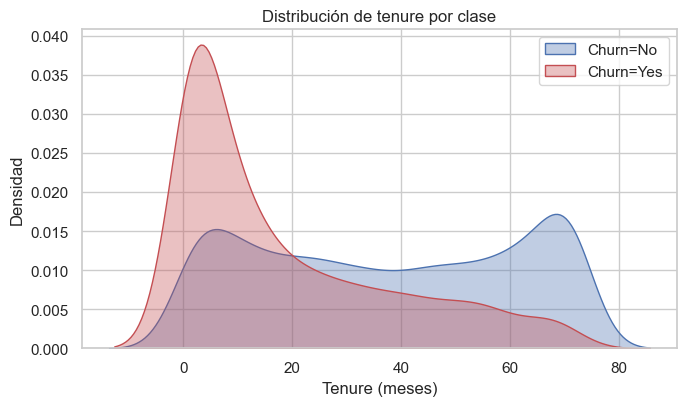

In [121]:
# Figura 3: Tenure por clase
fig, ax = plt.subplots(figsize=(7, 4.2))
for label, color in [('No', '#4C72B0'), ('Yes', '#C44E52')]:
    sns.kdeplot(
        df_eda.loc[df_eda['Churn'] == label, 'tenure'],
        ax=ax,
        label=f'Churn={label}',
        color=color,
        fill=True, alpha=0.35
    )
ax.set_title('Distribución de tenure por clase')
ax.set_xlabel('Tenure (meses)')
ax.set_ylabel('Densidad')
ax.legend()
plt.tight_layout()
plt.show()

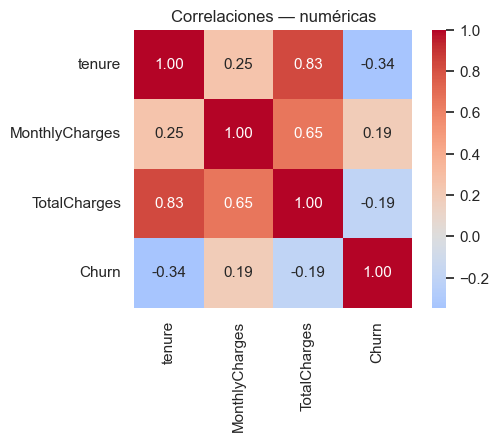

In [122]:
# Figura 4: Heatmap correlaciones
num = df_eda[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()
num['Churn'] = (df_eda['Churn'] == 'Yes').astype(int)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(
    num.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    ax=ax
)
ax.set_title('Correlaciones — numéricas')
plt.tight_layout()
plt.show()

## 3. Modelado: LogReg + Random Forest

- Se entrenaron dos modelos: **Regresión Logística L2** y **Random Forest**.
- La Regresión Logística es interpretable y usa regularización L2 para controlar sobreajuste.
- Random Forest permite capturar relaciones no lineales e interacciones entre variables.
- Se utilizó `StratifiedKFold(5)` para preservar la proporción de clases en cada fold.
- Se aplicó `GridSearchCV` optimizando F1-score, priorizando la clase positiva `Churn`.
- `class_weight='balanced'` ayuda a mitigar el desbalance de clases sin aplicar re-muestreo.
- Los modelos se entrenaron con `X_train`; la validación se usó para reportar métricas internas y ajustar los thresholds.

In [123]:
# 3. Modelado: LogReg + Random Forest

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Regresión Logística
lr_grid = {'C': [0.01, 0.1, 1.0, 10.0]}

lr = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    penalty='l2',
    solver='lbfgs',
    random_state=SEED
)

gs_lr = GridSearchCV(
    lr,
    lr_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1
)

gs_lr.fit(X_train, y_train)

print(f"[LR] best={gs_lr.best_params_} | CV F1={gs_lr.best_score_:.4f}")


# Random Forest
rf_grid = {
    'n_estimators': [200, 400],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 10]
}

rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1
)

gs_rf = GridSearchCV(
    rf,
    rf_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1
)

gs_rf.fit(X_train, y_train)

print(f"[RF] best={gs_rf.best_params_} | CV F1={gs_rf.best_score_:.4f}")

c:\Users\joeld\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


[LR] best={'C': 0.1} | CV F1=0.6230
[RF] best={'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200} | CV F1=0.6245


In [124]:
# Evaluación inicial en validación con threshold = 0.5
y_pred_lr_05 = gs_lr.predict(X_val)
y_pred_rf_05 = gs_rf.predict(X_val)

proba_lr_val = gs_lr.predict_proba(X_val)[:, 1]
proba_rf_val = gs_rf.predict_proba(X_val)[:, 1]
def metrics(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred)
    }

tabla_05 = pd.DataFrame({
    'LogReg': metrics(y_val, y_pred_lr_05),
    'RandomForest': metrics(y_val, y_pred_rf_05)
}).T.round(4)

print("=== Métricas en VALIDACIÓN (threshold=0.5) ===")
tabla_05

=== Métricas en VALIDACIÓN (threshold=0.5) ===


,accuracy,f1,precision,recall
LogReg,0.7560,0.6377,0.5261,0.8094
RandomForest,0.7728,0.6311,0.5544,0.7324


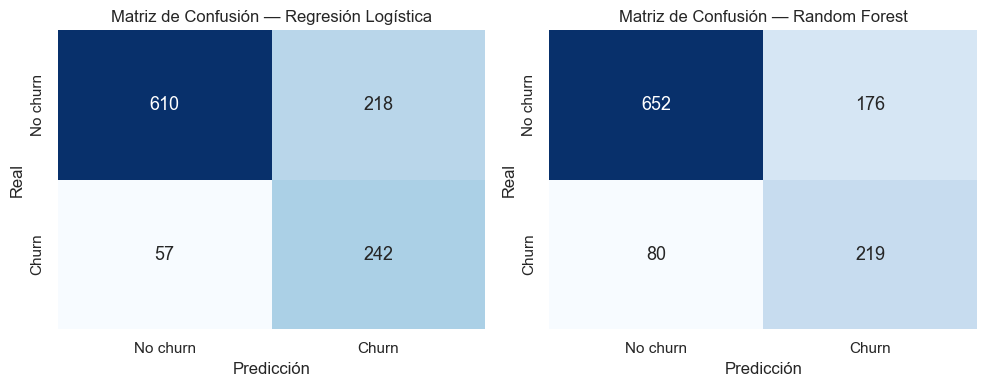

In [125]:
# =========================
# Matrices de confusión con threshold = 0.5
# =========================
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
cms = [
    confusion_matrix(y_val, y_pred_lr_05),
    confusion_matrix(y_val, y_pred_rf_05)
]
titles = ['Regresión Logística','Random Forest']
for ax, cm, title in zip(axes, cms, titles):
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',cbar=False,ax=ax,
        xticklabels=['No churn', 'Churn'],
        yticklabels=['No churn', 'Churn'],
        annot_kws={'size': 13}
    )
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')
    ax.set_title(f'Matriz de Confusión — {title}')
plt.tight_layout()
plt.show()

## 4. Matriz de Costos + Threshold óptimo

| Real \ Predicción | No churn | Churn |
|---|---:|---:|
| No churn | \$0 (TN) | \$45 (FP) |
| Churn    | \$420 (FN) | \$45 (TP) |

La matriz de costos representa una hipótesis de negocio para una campaña de retención. Predecir `Churn` implica activar una acción comercial, por lo que tanto FP como TP tienen un costo de campaña. En cambio, el falso negativo tiene el costo más alto porque representa perder un cliente que no fue detectado por el modelo.

El threshold óptimo se selecciona usando el conjunto de validación, buscando minimizar el costo total esperado.

In [126]:
# =========================
# 4. Matriz de costos + threshold óptimo
# =========================

C_TN, C_FP, C_FN, C_TP = 0, 45, 420, 45

def total_cost(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn*C_TN + fp*C_FP + fn*C_FN + tp*C_TP

proba_lr_val = gs_lr.predict_proba(X_val)[:, 1]
proba_rf_val = gs_rf.predict_proba(X_val)[:, 1]

ths = np.linspace(0.05, 0.95, 91)

c_lr = np.array([
    total_cost(y_val, (proba_lr_val >= t).astype(int))
    for t in ths
])

c_rf = np.array([
    total_cost(y_val, (proba_rf_val >= t).astype(int))
    for t in ths
])

best_t_lr = ths[c_lr.argmin()]
best_t_rf = ths[c_rf.argmin()]

best_c_lr = c_lr.min()
best_c_rf = c_rf.min()

default_c_lr = total_cost(y_val, (proba_lr_val >= 0.5).astype(int))
default_c_rf = total_cost(y_val, (proba_rf_val >= 0.5).astype(int))

print(f"LogReg:  t=0.5 → ${default_c_lr:,}    t*={best_t_lr:.2f} → ${best_c_lr:,}")
print(f"RForest: t=0.5 → ${default_c_rf:,}    t*={best_t_rf:.2f} → ${best_c_rf:,}")

winner = 'LogReg' if best_c_lr <= best_c_rf else 'RandomForest'
w_t = best_t_lr if winner == 'LogReg' else best_t_rf
w_proba_val = proba_lr_val if winner == 'LogReg' else proba_rf_val
w_cost_val = min(best_c_lr, best_c_rf)
w_base_val = default_c_lr if winner == 'LogReg' else default_c_rf

print(f"\n>>> Ganador costo-beneficio: {winner}")
print(f"Threshold óptimo: {w_t:.2f}")
print(f"Costo con t=0.5: ${w_base_val:,}")
print(f"Costo con t*={w_t:.2f}: ${w_cost_val:,}")
print(f"Ahorro: {(w_base_val-w_cost_val)/w_base_val*100:.1f}%")

LogReg:  t=0.5 → $44,640    t*=0.24 → $37,830
RForest: t=0.5 → $51,375    t*=0.22 → $37,785

>>> Ganador costo-beneficio: RandomForest
Threshold óptimo: 0.22
Costo con t=0.5: $51,375
Costo con t*=0.22: $37,785
Ahorro: 26.5%


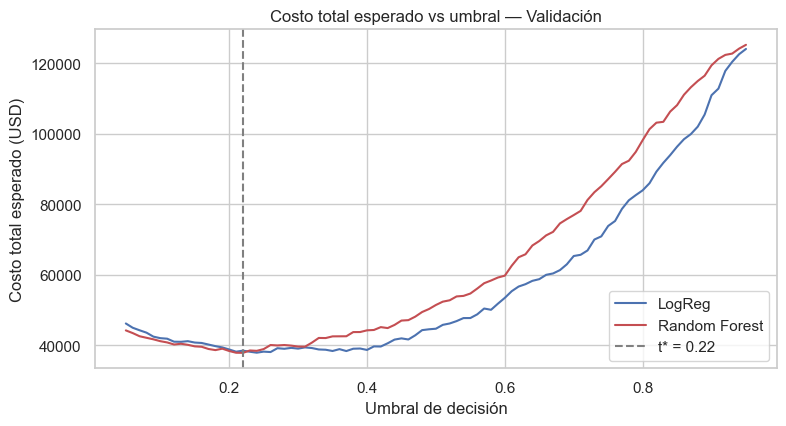

In [127]:
fig, ax = plt.subplots(figsize=(8, 4.4))
ax.plot(ths, c_lr, label='LogReg', color='#4C72B0')
ax.plot(ths, c_rf, label='Random Forest', color='#C44E52')
ax.axvline(w_t, color='gray', ls='--', label=f't* = {w_t:.2f}')
ax.set_xlabel('Umbral de decisión')
ax.set_ylabel('Costo total esperado (USD)')
ax.set_title('Costo total esperado vs umbral — Validación')
ax.legend()
plt.tight_layout()
plt.show()

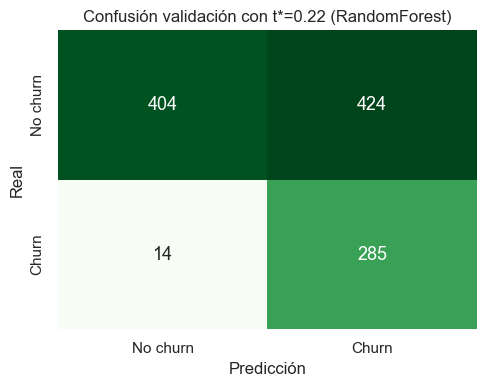

              precision    recall  f1-score   support

    No churn       0.97      0.49      0.65       828
       Churn       0.40      0.95      0.57       299

    accuracy                           0.61      1127
   macro avg       0.68      0.72      0.61      1127
weighted avg       0.82      0.61      0.63      1127

Costo validación con t=0.5: $51,375
Costo validación con t*=0.22: $37,785
Ahorro en validación: 26.5%


In [128]:
# Matriz de confusión con threshold óptimo de costo
y_pred_opt = (w_proba_val >= w_t).astype(int)
cm = confusion_matrix(y_val, y_pred_opt)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    cbar=False,
    xticklabels=['No churn', 'Churn'],
    yticklabels=['No churn', 'Churn'],
    ax=ax,
    annot_kws={'size': 13}
)

ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
ax.set_title(f'Confusión validación con t*={w_t:.2f} ({winner})')

plt.tight_layout()
plt.show()

print(classification_report(y_val, y_pred_opt, target_names=['No churn', 'Churn']))

val_cost_opt = total_cost(y_val, y_pred_opt)
val_cost_default = total_cost(y_val, (w_proba_val >= 0.5).astype(int))

print(f'Costo validación con t=0.5: ${val_cost_default:,}')
print(f'Costo validación con t*={w_t:.2f}: ${val_cost_opt:,}')
print(f'Ahorro en validación: {(val_cost_default-val_cost_opt)/val_cost_default*100:.1f}%')

### Comparación de thresholds alternativos

Se compararon distintos thresholds para observar cómo cambia la matriz de confusión y las métricas del modelo. Esto permite analizar el trade-off entre reducir falsos negativos, controlar falsos positivos y mejorar F1-score.

In [129]:
# Comparación de thresholds para analizar matriz de confusión

def resumen_threshold(y_true, proba, thresholds, model_name):
    rows = []

    for t in thresholds:
        y_pred = (proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        rows.append({
            'modelo': model_name,
            'threshold': t,
            'TN': tn,
            'FP': fp,
            'FN': fn,
            'TP': tp,
            'accuracy': accuracy_score(y_true, y_pred),
            'precision': precision_score(y_true, y_pred),
            'recall': recall_score(y_true, y_pred),
            'f1': f1_score(y_true, y_pred),
            'costo': total_cost(y_true, y_pred)
        })

    return pd.DataFrame(rows)


thresholds_comparar = [0.15, 0.20, 0.22, 0.25, 0.30, 0.40, 0.50]

tabla_thr_rf = resumen_threshold(
    y_val,
    proba_rf_val,
    thresholds_comparar,
    'RandomForest'
)

tabla_thr_lr = resumen_threshold(
    y_val,
    proba_lr_val,
    thresholds_comparar,
    'LogReg'
)

tabla_thresholds = pd.concat([tabla_thr_rf, tabla_thr_lr], ignore_index=True)

tabla_thresholds.round(4)

,modelo,threshold,TN,FP,FN,TP,accuracy,precision,recall,f1,costo
0,RandomForest,0.15,313,515,8,291,0.5359,0.3610,0.9732,0.5267,39630
1,RandomForest,0.20,384,444,13,286,0.5945,0.3918,0.9565,0.5559,38310
2,RandomForest,0.22,404,424,14,285,0.6114,0.4020,0.9532,0.5655,37785
3,RandomForest,0.25,447,381,22,277,0.6424,0.4210,0.9264,0.5789,38850
4,RandomForest,0.30,506,322,31,268,0.6868,0.4542,0.8963,0.6029,39570
5,RandomForest,0.40,587,241,53,246,0.7391,0.5051,0.8227,0.6260,44175
6,RandomForest,0.50,652,176,80,219,0.7728,0.5544,0.7324,0.6311,51375
7,LogReg,0.15,289,539,8,291,0.5146,0.3506,0.9732,0.5155,40710
8,LogReg,0.20,341,487,9,290,0.5599,0.3732,0.9699,0.5390,38745
9,LogReg,0.22,365,463,11,288,0.5794,0.3835,0.9632,0.5486,38415


Con la matriz de costos propuesta, el threshold que minimiza el costo esperado fue aproximadamente `0.22` para Random Forest. Esta configuración obtiene una matriz de confusión con `TN=404`, `FP=424`, `FN=14` y `TP=285`.

Esto significa que el modelo detecta 285 de 299 clientes que realmente harían churn, manteniendo un recall alto cercano al 95%. A diferencia de thresholds demasiado bajos, esta opción reduce la cantidad de falsos positivos sin dejar escapar demasiados churners.

Por ello, `RandomForest` con threshold `0.22` se considera la configuración costo-beneficio final. La elección de este threshold representa un punto intermedio entre minimizar la pérdida de clientes y evitar una cantidad excesiva de falsas alarmas.

## 5. Predicciones finales con criterio costo-beneficio

El archivo `test.csv` oficial no contiene la variable objetivo `Churn`, por lo que no se utiliza para calcular métricas. En esta sección se generan predicciones finales usando el modelo y threshold seleccionados por la matriz de costos.

Con la matriz de costos propuesta, la configuración seleccionada fue `RandomForest` con threshold `0.22`. Esta versión prioriza detectar la mayor cantidad posible de clientes con riesgo de churn, pero evitando un threshold excesivamente bajo que genere demasiadas falsas alarmas.

In [130]:
# 5. Predicciones finales con criterio costo-beneficio

if winner == 'LogReg':
    final_model_cost_benefit = gs_lr
else:
    final_model_cost_benefit = gs_rf

threshold_cost_benefit = w_t

proba_test_oficial_cost_benefit = final_model_cost_benefit.predict_proba(X_test_oficial_enc)[:, 1]
pred_test_oficial_cost_benefit = (proba_test_oficial_cost_benefit >= threshold_cost_benefit).astype(int)

submission_cost_benefit = pd.DataFrame({
    'customerID': test_customer_ids,
    'Churn': pred_test_oficial_cost_benefit
})

submission_cost_benefit['Churn'] = submission_cost_benefit['Churn'].map({
    0: 'No',
    1: 'Yes'
})

print("Submission costo-beneficio:")
print(submission_cost_benefit.head())
print(submission_cost_benefit['Churn'].value_counts())

submission_cost_benefit.to_csv('../submission_threshold_costo_beneficio.csv', index=False)

print(f"Archivo guardado: submission_threshold_costo_beneficio.csv")
print(f"Modelo usado: {winner}")
print(f"Threshold usado: {threshold_cost_benefit:.2f}")

Submission costo-beneficio:
   customerID Churn
0  1024-GUALD   Yes
1  0484-JPBRU    No
2  3620-EHIMZ    No
3  6910-HADCM   Yes
4  8587-XYZSF    No
Churn
Yes    867
No     542
Name: count, dtype: int64
Archivo guardado: submission_threshold_costo_beneficio.csv
Modelo usado: RandomForest
Threshold usado: 0.22


In [131]:
resumen_costo_beneficio = pd.DataFrame({
    'Criterio': ['Costo-beneficio'],
    'Modelo': ['RandomForest'],
    'Threshold': [0.22],
    'Motivo': [
        'Minimiza el costo esperado bajo la matriz propuesta y mantiene recall alto'
    ]
})

pd.set_option('display.max_colwidth', None)
resumen_costo_beneficio

,Criterio,Modelo,Threshold,Motivo
0,Costo-beneficio,RandomForest,0.22,Minimiza el costo esperado bajo la matriz propuesta y mantiene recall alto


Se generó un archivo de predicción bajo el criterio costo-beneficio: `submission_threshold_costo_beneficio.csv`. Este archivo utiliza el modelo Random Forest con threshold `0.22`, que fue el umbral que minimizó el costo esperado según la matriz de costos propuesta. Esta configuración busca detectar la mayor cantidad posible de clientes con riesgo de churn, manteniendo un balance razonable entre falsos positivos y falsos negativos.

## 6. Submission Kaggle/Cadem optimizada por F1-score

Aunque el análisis costo-beneficio utiliza una matriz de costos, la evaluación oficial de Kaggle/Cadem utiliza F1-score. Por ello, se realiza una optimización separada del threshold, buscando maximizar F1 sobre el conjunto de validación.

Además, se usa `sample_submission.csv` como plantilla final porque Kaggle espera exactamente los `customerID` de ese archivo y en el mismo orden. Al verificar los IDs, se observó que `sample_submission.csv` no coincidía completamente con `test.csv`, por lo que se construyó un conjunto de predicción combinando las filas disponibles en `test.csv` y `train.csv`.

In [132]:
# 6.1 Buscar threshold óptimo por F1 para Kaggle/Cadem

proba_lr_val = gs_lr.predict_proba(X_val)[:, 1]
proba_rf_val = gs_rf.predict_proba(X_val)[:, 1]

ths_f1 = np.arange(0.05, 0.96, 0.005)

resultados_f1 = []

for model_name, proba in {
    'LogReg': proba_lr_val,
    'RandomForest': proba_rf_val
}.items():

    for t in ths_f1:
        y_pred = (proba >= t).astype(int)

        resultados_f1.append({
            'modelo': model_name,
            'threshold': t,
            'accuracy': accuracy_score(y_val, y_pred),
            'precision': precision_score(y_val, y_pred),
            'recall': recall_score(y_val, y_pred),
            'f1': f1_score(y_val, y_pred)
        })

tabla_f1 = pd.DataFrame(resultados_f1)

best_f1_row = tabla_f1.sort_values('f1', ascending=False).iloc[0]

winner_f1 = best_f1_row['modelo']
w_t_f1 = best_f1_row['threshold']

print("Ganador F1:", winner_f1)
print("Threshold F1:", round(w_t_f1, 3))
print("F1 validación:", round(best_f1_row['f1'], 4))
print("Accuracy validación:", round(best_f1_row['accuracy'], 4))
print("Precision:", round(best_f1_row['precision'], 4))
print("Recall:", round(best_f1_row['recall'], 4))

tabla_f1.sort_values('f1', ascending=False).head(10)

Ganador F1: LogReg
Threshold F1: 0.555
F1 validación: 0.6561
Accuracy validación: 0.7879
Precision: 0.5758
Recall: 0.7625


,modelo,threshold,accuracy,precision,recall,f1
101,LogReg,0.555,0.787933,0.575758,0.762542,0.656115
107,LogReg,0.585,0.795031,0.591892,0.732441,0.654709
106,LogReg,0.580,0.793256,0.588235,0.735786,0.653789
103,LogReg,0.565,0.788820,0.578811,0.749164,0.653061
102,LogReg,0.560,0.786158,0.573980,0.752508,0.651230
105,LogReg,0.575,0.789707,0.582011,0.735786,0.649926
100,LogReg,0.550,0.780834,0.564039,0.765886,0.649645
99,LogReg,0.545,0.777285,0.558252,0.769231,0.646976
108,LogReg,0.590,0.791482,0.587432,0.719064,0.646617
104,LogReg,0.570,0.786158,0.575916,0.735786,0.646109


In [133]:
# 6.2 Evaluar configuración ganadora por F1 en validación

if winner_f1 == 'LogReg':
    proba_val_f1 = gs_lr.predict_proba(X_val)[:, 1]
else:
    proba_val_f1 = gs_rf.predict_proba(X_val)[:, 1]

y_pred_f1 = (proba_val_f1 >= w_t_f1).astype(int)

print(classification_report(y_val, y_pred_f1, target_names=['No churn', 'Churn']))
print("F1 validación:", round(f1_score(y_val, y_pred_f1), 4))
print("Accuracy validación:", round(accuracy_score(y_val, y_pred_f1), 4))

              precision    recall  f1-score   support

    No churn       0.90      0.80      0.85       828
       Churn       0.58      0.76      0.66       299

    accuracy                           0.79      1127
   macro avg       0.74      0.78      0.75      1127
weighted avg       0.82      0.79      0.80      1127

F1 validación: 0.6561
Accuracy validación: 0.7879


In [134]:
# 6.3 Verificar IDs del sample_submission


train_df = pd.read_csv("../train.csv")
test_df = pd.read_csv("../test.csv")
sample_submission = pd.read_csv("../sample_submission.csv")

ids_sample = set(sample_submission['customerID'])
ids_test = set(test_df['customerID'])
ids_train = set(train_df['customerID'])

print("IDs en sample:", len(ids_sample))
print("IDs en test:", len(ids_test))
print("IDs en train:", len(ids_train))

print("\nCoincidencias sample-test:", len(ids_sample & ids_test))
print("Coincidencias sample-train:", len(ids_sample & ids_train))

print("\nIDs del sample que NO están ni en train ni en test:")
print(len(ids_sample - ids_test - ids_train))

print("\nIDs del sample que no están en test:")
print(len(ids_sample - ids_test))

print("\nIDs del test que no están en sample:")
print(len(ids_test - ids_sample))

IDs en sample: 1409
IDs en test: 1409
IDs en train: 5634

Coincidencias sample-test: 287
Coincidencias sample-train: 1122

IDs del sample que NO están ni en train ni en test:
0

IDs del sample que no están en test:
1122

IDs del test que no están en sample:
1122


In [135]:
# 6.4 Construir filas de predicción en el orden del sample_submission

sample_submission = pd.read_csv("../sample_submission.csv")

train_para_pred = train_df.copy()
test_para_pred = test_df.copy()

if 'Churn' in train_para_pred.columns:
    train_para_pred = train_para_pred.drop(columns=['Churn'])

df_pool = pd.concat([test_para_pred, train_para_pred], ignore_index=True)

df_pool = df_pool.drop_duplicates(subset='customerID', keep='first')

df_sample_features = sample_submission[['customerID']].merge(
    df_pool,
    on='customerID',
    how='left'
)

print("Shape sample_submission:", sample_submission.shape)
print("Shape features para predecir:", df_sample_features.shape)

faltantes = df_sample_features[df_sample_features.drop(columns=['customerID']).isna().all(axis=1)]

print("IDs sin features:", len(faltantes))

if len(faltantes) > 0:
    print(faltantes['customerID'].head(20).tolist())


Shape sample_submission: (1409, 2)
Shape features para predecir: (1409, 20)
IDs sin features: 0


In [136]:
# 6.5 Preprocesar filas del sample_submission

sample_customer_ids = df_sample_features['customerID'].copy()

resultado_clean = clean(df_sample_features)

if isinstance(resultado_clean, tuple):
    df_sample_clean = resultado_clean[0]
else:
    df_sample_clean = resultado_clean

df_sample_fe = feature_engineer(df_sample_clean)

def encode_features_only(df):
    df = df.copy()

    df['gender'] = (df['gender'] == 'Male').astype(int)

    for c in ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']:
        df[c] = (df[c] == 'Yes').astype(int)

    for c in SERVICE_COLS + ['MultipleLines']:
        df[c] = (df[c] == 'Yes').astype(int)

    cat = ['InternetService', 'Contract', 'PaymentMethod', 'tenure_bucket']
    df = pd.get_dummies(df, columns=cat, drop_first=True, dtype=int)

    return df

X_sample_enc = encode_features_only(df_sample_fe)

X_sample_enc = X_sample_enc.reindex(columns=X_train.columns, fill_value=0)

X_sample_enc[SCALED_NUMERIC] = scaler.transform(X_sample_enc[SCALED_NUMERIC])

print("Shape final para sample:", X_sample_enc.shape)

Shape final para sample: (1409, 29)


In [139]:
# 6.6 Generar submission final Kaggle/Cadem
# Formato aceptado: Yes/No

if winner_f1 == 'LogReg':
    final_model_kaggle = gs_lr
else:
    final_model_kaggle = gs_rf

proba_sample_kaggle = final_model_kaggle.predict_proba(X_sample_enc)[:, 1]
pred_sample_kaggle = (proba_sample_kaggle >= w_t_f1).astype(int)

submission_kaggle_yesno = pd.DataFrame({
    'customerID': sample_submission['customerID'],
    'Churn': pred_sample_kaggle
})

submission_kaggle_yesno['Churn'] = submission_kaggle_yesno['Churn'].map({
    0: 'No',
    1: 'Yes'
})

print("Submission Kaggle/Cadem:")
print(submission_kaggle_yesno.head())
print(submission_kaggle_yesno.shape)
print(submission_kaggle_yesno['Churn'].value_counts())

print("IDs iguales al sample:", submission_kaggle_yesno['customerID'].equals(sample_submission['customerID']))
print("Nulos en Churn:", submission_kaggle_yesno['Churn'].isna().sum())
print("Valores únicos:", submission_kaggle_yesno['Churn'].unique())

submission_kaggle_yesno.to_csv("../submission_kaggle_yesno.csv", index=False)

print("Archivo guardado: submission_kaggle_yesno.csv")

Submission Kaggle/Cadem:
   customerID Churn
0  4376-KFVRS    No
1  2754-SDJRD   Yes
2  9917-KWRBE    No
3  0365-GXEZS    No
4  9385-NXKDA    No
(1409, 2)
Churn
No     884
Yes    525
Name: count, dtype: int64
IDs iguales al sample: True
Nulos en Churn: 0
Valores únicos: ['No' 'Yes']
Archivo guardado: submission_kaggle_yesno.csv


In [138]:
resumen_kaggle = pd.DataFrame({
    'Criterio': ['Kaggle/Cadem F1'],
    'Modelo': [winner_f1],
    'Threshold': [round(w_t_f1, 3)],
    'F1 validación': [round(f1_score(y_val, y_pred_f1), 4)],
    'Archivo': ['submission_kaggle_yesno.csv']
})

resumen_kaggle

,Criterio,Modelo,Threshold,F1 validación,Archivo
0,Kaggle/Cadem F1,LogReg,0.555,0.6561,submission_kaggle_yesno.csv


## Conclusiones

1. Se construyó un pipeline completo para predecir churn, incluyendo preprocesamiento, ingeniería de variables, EDA, modelado, validación cruzada y análisis de thresholds.

2. Con threshold base `0.5`, Random Forest obtuvo mayor accuracy, mientras que Regresión Logística obtuvo mayor recall para la clase Churn. Esto muestra que la elección del modelo depende del objetivo.

3. Para el análisis costo-beneficio se definió una matriz de costos donde perder un cliente tiene mayor penalización que realizar una campaña innecesaria. Bajo esta matriz, la mejor configuración fue `RandomForest` con threshold `0.22`.

4. La matriz de confusión de `RandomForest t=0.22` mostró `TN=404`, `FP=424`, `FN=14` y `TP=285`, detectando 285 de 299 churners reales en validación.

5. Para Kaggle/Cadem se priorizó F1-score, ya que es la métrica oficial. Bajo ese criterio, la mejor configuración fue `LogReg` con threshold `0.55`.

6. El análisis evidencia que no existe un único threshold óptimo para todos los objetivos: `0.22` responde al criterio costo-beneficio, mientras que `0.55` responde a la métrica oficial F1-score.